# 01 · Data Understanding — Home Credit Default Risk

**Project:** Credit Default Risk — AI Governance Portfolio (Notebook 1 of the pipeline)

---

## Why this notebook exists

Before any modeling, a **high-risk credit AI system** must be *understood and documented*.
This notebook is the first governance artifact: it inventories the raw data, fixes the
schema, and **names the protected attributes up front** so the Fair Lending audit later
is auditable rather than an afterthought.

### Regulatory framing (this is the differentiator vs. a typical ML portfolio)

| Framework | Why this dataset is in scope |
|---|---|
| **EU AI Act — Annex III §5(b)** | AI used to **evaluate creditworthiness / establish credit scores** is classified **High-Risk**. It triggers obligations on data governance, transparency, human oversight, and bias monitoring. |
| **US Fair Lending — ECOA / Regulation B** | Credit decisions may not discriminate on **prohibited bases**: sex, marital status, age, national origin, etc. We must identify those attributes (and their proxies) in the data *now*. |

### What we deliver here
1. Load all 10 tables and produce a single **overview** (shape, dtypes, memory, missing %).
2. Inspect the **TARGET** (default) distribution and the class imbalance.
3. **Categorize** the 122 columns of the main table into business groups.
4. Diagram how the 9 auxiliary tables join to the main table via **SK_ID** keys.
5. ⭐ Explicitly flag the **protected attributes** for the Fair Lending audit.
6. Visualize **missing values** (a major data-quality issue here).
7. Hand off to **`02_eda_main_table`**.


## 0 · Setup

Import libraries and set a few display/plot defaults so output is readable.

In [1]:
# --- Core data libraries ---
import os                      # build file paths in an OS-independent way
import warnings                # used to silence noisy, non-actionable warnings
import numpy as np             # numerical arrays / fast math
import pandas as pd            # the main table/dataframe library

# --- Plotting libraries ---
import matplotlib.pyplot as plt   # base plotting engine
import seaborn as sns             # higher-level statistical charts on top of matplotlib

# --- Display defaults (so wide Home Credit tables are actually readable) ---
pd.set_option("display.max_columns", 200)   # show up to 200 columns without truncation
pd.set_option("display.width", 200)         # use a wide console layout
sns.set_theme(style="whitegrid")            # clean grid background for all charts
warnings.filterwarnings("ignore")           # hide deprecation noise; keep notebook output clean

# --- Project paths ---
DATA_DIR = "../data"          # raw CSVs live one level up, in /data
RESULTS_DIR = "../results"    # we save every figure here so docs/ can reference them
os.makedirs(RESULTS_DIR, exist_ok=True)   # create /results if it does not exist yet

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.3 | numpy 2.4.6


## 1 · Load all 10 tables and build a single overview

The dataset ships as **10 CSV files** (~2.5 GB total). Three of them have **tens of
millions of rows**, so loading every table and *keeping it in memory at once* would
exhaust a 16 GB machine.

**Strategy (and good practice):** load each table **one at a time**, record its
metadata (shape, dtypes, memory, missing %), then **free it** before loading the next.
The only table we keep resident is the main `application_train`, which the rest of the
notebook analyzes.


In [2]:
# Map a short, human-friendly name -> CSV filename for every table we want to inventory.
TABLES = {
    "application_train":    "application_train.csv",     # main table: 1 row per loan applicant (has TARGET)
    "application_test":     "application_test.csv",       # same schema, no TARGET (Kaggle scoring set)
    "bureau":               "bureau.csv",                 # prior credits at OTHER institutions (credit bureau)
    "bureau_balance":       "bureau_balance.csv",         # monthly balance history for each bureau credit
    "previous_application": "previous_application.csv",   # the client's previous Home Credit applications
    "POS_CASH_balance":     "POS_CASH_balance.csv",       # monthly POS / cash-loan balances (Home Credit)
    "installments_payments":"installments_payments.csv",  # repayment history on previous Home Credit loans
    "credit_card_balance":  "credit_card_balance.csv",    # monthly credit-card balances (Home Credit)
    "sample_submission":    "sample_submission.csv",      # Kaggle submission template (ids + prediction column)
}

def summarize_table(path):
    "Load one CSV, compute lightweight metadata, then discard the heavy dataframe."
    df = pd.read_csv(path)                                  # read the full file into memory
    meta = {
        "rows": df.shape[0],                                # number of records
        "cols": df.shape[1],                                # number of columns
        "memory_MB": round(df.memory_usage(deep=True).sum() / 1024**2, 1),  # true in-RAM size (deep=True counts strings)
        "numeric_cols": df.select_dtypes("number").shape[1],            # count numeric columns
        "categorical_cols": df.select_dtypes(exclude="number").shape[1],# count text/categorical columns
        "missing_pct": round(df.isna().mean().mean() * 100, 1),         # avg % of cells that are NaN
        "SK_ID_keys": [c for c in df.columns if c.startswith("SK_ID")], # which join keys this table carries
    }
    del df                                                  # release the dataframe so RAM is freed
    return meta

# Build the overview row-by-row (one table loaded at a time).
overview_rows = {}
for name, fname in TABLES.items():
    overview_rows[name] = summarize_table(os.path.join(DATA_DIR, fname))
    print(f"summarized {name:24s} -> {overview_rows[name]['rows']:>10,} rows")

# Turn the dict of metadata into a tidy dataframe for display.
overview = pd.DataFrame(overview_rows).T
overview = overview[["rows", "cols", "numeric_cols", "categorical_cols",
                     "missing_pct", "memory_MB", "SK_ID_keys"]]
overview

summarized application_train        ->    307,511 rows


summarized application_test         ->     48,744 rows


summarized bureau                   ->  1,716,428 rows


summarized bureau_balance           -> 27,299,925 rows


summarized previous_application     ->  1,670,214 rows


summarized POS_CASH_balance         -> 10,001,358 rows


summarized installments_payments    -> 13,605,401 rows


summarized credit_card_balance      ->  3,840,312 rows
summarized sample_submission        ->     48,744 rows


,rows,cols,numeric_cols,categorical_cols,missing_pct,memory_MB,SK_ID_keys
application_train,307511,122,106,16,24.4,505.0,[SK_ID_CURR]
application_test,48744,121,105,16,23.8,79.7,[SK_ID_CURR]
bureau,1716428,17,14,3,13.5,472.8,"[SK_ID_CURR, SK_ID_BUREAU]"
bureau_balance,27299925,3,2,1,0.0,1718.3,[SK_ID_BUREAU]
previous_application,1670214,37,21,16,18.0,1703.0,"[SK_ID_PREV, SK_ID_CURR]"
POS_CASH_balance,10001358,8,7,1,0.1,1060.9,"[SK_ID_PREV, SK_ID_CURR]"
installments_payments,13605401,8,8,0,0.0,830.4,"[SK_ID_PREV, SK_ID_CURR]"
credit_card_balance,3840312,23,22,1,6.7,846.4,"[SK_ID_PREV, SK_ID_CURR]"
sample_submission,48744,2,2,0,0.0,0.7,[SK_ID_CURR]


**How to read the overview**

- `application_train` (307,511 × 122) is small relative to the auxiliary tables.
- `bureau_balance` (27.3 M rows), `installments_payments` (13.6 M), and `POS_CASH_balance`
  (10.0 M) are huge — any feature from them must be **aggregated to one row per applicant**
  before joining (done in a later notebook).
- The `SK_ID_keys` column already tells us how the tables connect — formalized in §4.


### Load the main table once (used by §2, §3, §5, §6)

In [3]:
# Load application_train and KEEP it resident — every later section analyzes this table.
app = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))

# Quick sanity check on shape and the first few columns.
print("application_train:", app.shape[0], "rows x", app.shape[1], "columns")
app.head(3)

application_train: 307511 rows x 122 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 2 · TARGET distribution — the label we will predict

`TARGET` is binary, defined by Home Credit as:
- **1** — client had **payment difficulties** (late payment beyond a threshold on early installments) → *default*
- **0** — all other cases → *repaid on time*

Class balance drives every downstream choice (resampling, class weights, threshold tuning,
and which metric is honest). We expect a strong imbalance (~8% default).


Class counts:
 TARGET
0    282686
1     24825

Default rate (TARGET=1): 8.07%
Imbalance ratio (0:1): 11.4 : 1


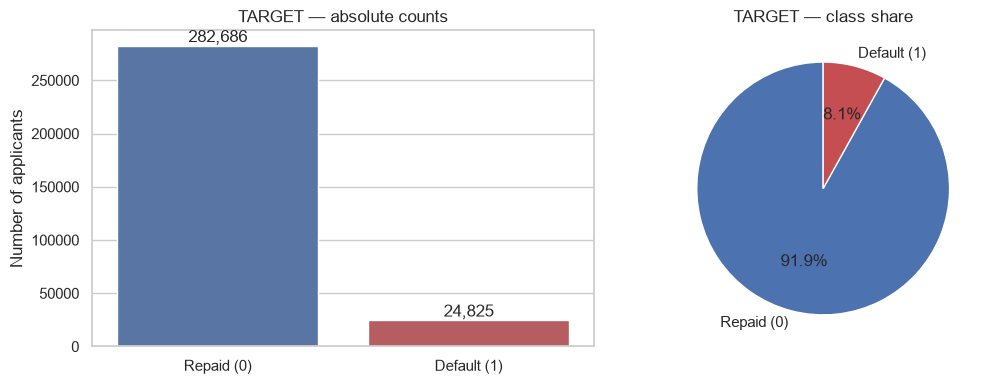

In [4]:
# Count each class and convert to percentages.
target_counts = app["TARGET"].value_counts().sort_index()     # 0 then 1
target_pct = app["TARGET"].value_counts(normalize=True).sort_index() * 100  # as %

# Print the exact numbers we will quote in documentation.
print("Class counts:\n", target_counts.to_string())
print(f"\nDefault rate (TARGET=1): {app['TARGET'].mean()*100:.2f}%")
print(f"Imbalance ratio (0:1): {target_counts[0]/target_counts[1]:.1f} : 1")

# --- Visualize the imbalance ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4))                 # two panels side by side
labels = ["Repaid (0)", "Default (1)"]                        # readable class names

# Left: absolute counts as a bar chart.
sns.barplot(x=labels, y=target_counts.values, ax=ax[0], palette=["#4C72B0", "#C44E52"])
ax[0].set_title("TARGET — absolute counts")
ax[0].set_ylabel("Number of applicants")
for i, v in enumerate(target_counts.values):                  # annotate each bar with its count
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Right: share of each class as a pie chart.
ax[1].pie(target_pct.values, labels=labels, autopct="%1.1f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("TARGET — class share")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "01_target_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.** Only **~8.07%** of applicants default (≈11.4 : 1 imbalance).
Consequences we must respect downstream:
- **Accuracy is misleading** — predicting "everyone repays" scores ~92% but catches zero defaults.
- We will rely on **Precision-Recall AUC, recall on defaulters, and a cost-sensitive
  threshold**, not raw accuracy.
- This imbalance is also a **fairness risk**: a model can hit good aggregate metrics while
  failing badly on a small subgroup — which is exactly what the Fair Lending audit checks.


## 3 · Categorize the 122 columns of `application_train`

122 columns is too many to reason about individually. We group every column into a
**business category** with a rule-based classifier, then verify the categories cover
**all 122 columns** (no column left behind — important for an auditable inventory).


In [5]:
def categorize(col):
    "Assign one application_train column to a business category. First rule that matches wins."
    if col in ("SK_ID_CURR", "TARGET"):                                   # primary key + label
        return "ID & Target"
    if col in {"CODE_GENDER", "DAYS_BIRTH", "NAME_FAMILY_STATUS",          # Fair Lending attributes
               "CNT_CHILDREN", "CNT_FAM_MEMBERS", "NAME_EDUCATION_TYPE"}:
        return "Demographic / Protected"
    if col.startswith("EXT_SOURCE"):                                      # 3 external credit scores
        return "External credit score"
    if col.startswith("FLAG_DOCUMENT"):                                   # 20 "did client provide doc N" flags
        return "Document flags"
    if col.startswith("AMT_REQ_CREDIT_BUREAU"):                           # # of credit-bureau inquiries
        return "Credit bureau inquiries"
    if col.endswith(("_AVG", "_MODE", "_MEDI")):                          # 47 normalized building/housing stats
        return "Housing / building stats"
    if "SOCIAL_CIRCLE" in col:                                            # defaults among the client's social circle
        return "Social circle"
    if col.startswith(("REGION", "REG_", "LIVE_")) or "CITY" in col:      # where the client lives/works
        return "Region / location"
    if col in {"NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE",# job + asset ownership
               "NAME_HOUSING_TYPE", "DAYS_EMPLOYED", "FLAG_EMP_PHONE",
               "OWN_CAR_AGE", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"}:
        return "Employment / assets"
    if col.startswith("AMT_"):                                            # income, credit, annuity, goods price
        return "Financial (amounts)"
    if col in {"NAME_CONTRACT_TYPE", "WEEKDAY_APPR_PROCESS_START",        # how/when the application was filed
               "HOUR_APPR_PROCESS_START", "NAME_TYPE_SUITE"} or "APPR_PROCESS_START" in col:
        return "Application / contract"
    if col.startswith("FLAG_"):                                           # remaining contact/availability flags
        return "Contact / flags"
    if col.startswith("DAYS_"):                                           # other day-count history fields
        return "Application history (days)"
    return "Other"                                                        # safety net (should stay empty)

# Apply the classifier to every column and count per category.
col_category = pd.Series({c: categorize(c) for c in app.columns}, name="category")
category_counts = col_category.value_counts()

# Verify the inventory is complete and exhaustive.
assert col_category.shape[0] == 122, "expected 122 columns"
assert (col_category == "Other").sum() == 0, "some columns were not categorized!"
print("All 122 columns categorized, 0 uncategorized.\n")
category_counts.to_frame("n_columns")

All 122 columns categorized, 0 uncategorized.



,n_columns
category,
Housing / building stats,47
Document flags,20
Employment / assets,9
Region / location,9
Demographic / Protected,6
Credit bureau inquiries,6
Contact / flags,5
Application / contract,4
Financial (amounts),4


**Interpretation.**
- The largest block — **47 "Housing / building stats"** (`*_AVG/_MODE/_MEDI`) — is also
  the one with the worst missingness (§6). Much of it is likely droppable.
- **20 "Document flags"** are near-constant binary indicators; most carry little signal.
- The analytically dense, predictive groups are small: **3 external credit scores**,
  **4 financial amounts**, and the **6 demographic/protected** fields — the last of which
  is the focus of the Fair Lending audit.


In [6]:
# Show the actual column names inside the two most governance-relevant categories.
for cat in ["Demographic / Protected", "External credit score", "Financial (amounts)"]:
    members = col_category[col_category == cat].index.tolist()
    print(f"{cat} ({len(members)}):\n  {members}\n")

Demographic / Protected (6):
  ['CODE_GENDER', 'CNT_CHILDREN', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'DAYS_BIRTH', 'CNT_FAM_MEMBERS']

External credit score (3):
  ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Financial (amounts) (4):
  ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']



## 4 · How the 9 auxiliary tables join to the main table

There are **three join keys**:
- **`SK_ID_CURR`** — one current loan application (the grain of `application_train`).
- **`SK_ID_PREV`** — one *previous* Home Credit application.
- **`SK_ID_BUREAU`** — one credit recorded at an external bureau.

The schema is **hub-and-spoke with a second level**:

```
                          application_train / application_test
                                   (SK_ID_CURR)   ← the hub, 1 row per applicant
                                        │
        ┌───────────────┬───────────────┼───────────────────────────┐
        │ SK_ID_CURR    │ SK_ID_CURR    │ SK_ID_CURR                 │ SK_ID_CURR
        ▼               ▼               ▼                            ▼
     bureau       previous_application  POS_CASH_balance      installments_payments
   (SK_ID_BUREAU)   (SK_ID_PREV)        (SK_ID_PREV)            (SK_ID_PREV)
        │               │  (and credit_card_balance, also keyed by SK_ID_PREV + SK_ID_CURR)
        │ SK_ID_BUREAU  │ SK_ID_PREV
        ▼               ▼
  bureau_balance   POS_CASH / installments / credit_card  (monthly rows under each prev application)
```

- `bureau_balance` does **not** carry `SK_ID_CURR`; it links to an applicant only
  **through** `bureau` (`SK_ID_BUREAU` → `SK_ID_CURR`). That two-hop path is a classic
  place to introduce join bugs, so we document it explicitly.
- All the monthly tables are **one-to-many** vs. the applicant, so they must be
  **aggregated** (counts, means, recent values) before joining — done in `02`/`03`.


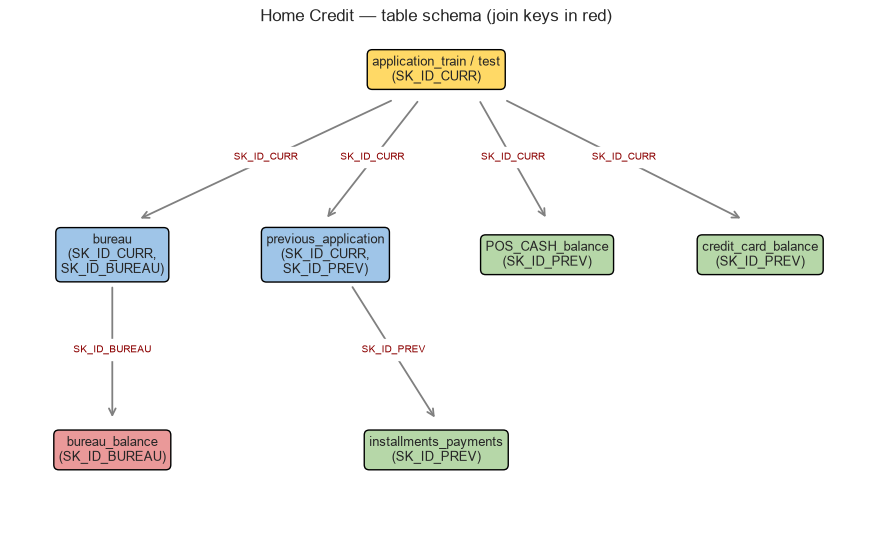

In [7]:
# Draw the schema as a simple box-and-arrow figure for the model card / docs.
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axis("off")   # we are drawing a diagram, not a data plot — hide axes

def box(x, y, text, color):
    "Draw a labelled rounded box centered at (x, y)."
    ax.text(x, y, text, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="black"))

def arrow(x1, y1, x2, y2, label):
    "Draw an arrow from (x1,y1) to (x2,y2) annotated with the join key."
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.3))
    ax.text((x1+x2)/2, (y1+y2)/2, label, fontsize=7.5, color="darkred",
            ha="center", backgroundcolor="white")

# Hub (level 0)
box(0.5, 0.92, "application_train / test\n(SK_ID_CURR)", "#FFD966")
# Level 1 — joined directly on SK_ID_CURR
box(0.12, 0.55, "bureau\n(SK_ID_CURR,\nSK_ID_BUREAU)", "#9FC5E8")
box(0.37, 0.55, "previous_application\n(SK_ID_CURR,\nSK_ID_PREV)", "#9FC5E8")
box(0.63, 0.55, "POS_CASH_balance\n(SK_ID_PREV)", "#B6D7A8")
box(0.88, 0.55, "credit_card_balance\n(SK_ID_PREV)", "#B6D7A8")
# Level 2
box(0.12, 0.16, "bureau_balance\n(SK_ID_BUREAU)", "#EA9999")
box(0.50, 0.16, "installments_payments\n(SK_ID_PREV)", "#B6D7A8")

# Arrows hub -> level 1
arrow(0.45, 0.86, 0.15, 0.62, "SK_ID_CURR")
arrow(0.48, 0.86, 0.37, 0.62, "SK_ID_CURR")
arrow(0.55, 0.86, 0.63, 0.62, "SK_ID_CURR")
arrow(0.58, 0.86, 0.86, 0.62, "SK_ID_CURR")
# Arrows level 1 -> level 2
arrow(0.12, 0.49, 0.12, 0.22, "SK_ID_BUREAU")
arrow(0.40, 0.49, 0.50, 0.22, "SK_ID_PREV")

ax.set_title("Home Credit — table schema (join keys in red)", fontsize=12)
plt.savefig(os.path.join(RESULTS_DIR, "01_schema_diagram.png"), dpi=120, bbox_inches="tight")
plt.show()

## 5 · ⭐ Protected attributes — Fair Lending audit targets

This is the core governance step. We **name the protected attributes now** so the later
fairness audit (`04`) is reproducible and defensible. Each maps to a prohibited basis
under **ECOA / Regulation B** and is a bias-monitoring obligation under the **EU AI Act**.

| Column | What it is | Prohibited basis it represents |
|---|---|---|
| `CODE_GENDER` | Client gender | **Sex** |
| `NAME_FAMILY_STATUS` | Marital status | **Marital status** |
| `DAYS_BIRTH` | Age (negative days from application) | **Age** |
| `CNT_CHILDREN` | Number of children | **Familial status** (proxy) |
| `NAME_EDUCATION_TYPE` | Education level | Disparate-impact **proxy** (correlates with race/income) |

We inspect each one's distribution and flag **data-quality issues** (ambiguous categories
like `XNA`/`Unknown`) that themselves create fairness risk.


In [8]:
# The attributes we will audit, plus a derived AGE in years from DAYS_BIRTH.
app["AGE_YEARS"] = (-app["DAYS_BIRTH"] / 365.25).round(1)   # DAYS_BIRTH is negative days before application

protected = ["CODE_GENDER", "NAME_FAMILY_STATUS", "CNT_CHILDREN", "NAME_EDUCATION_TYPE"]

# Print the value counts for each categorical/discrete protected attribute.
for col in protected:
    print(f"=== {col} ===")
    print(app[col].value_counts(dropna=False).to_string())
    print()

# Age is continuous — describe it instead of value-counting.
print("=== AGE_YEARS (from DAYS_BIRTH) ===")
print(app["AGE_YEARS"].describe().round(1).to_string())

=== CODE_GENDER ===
CODE_GENDER
F      202448
M      105059
XNA         4

=== NAME_FAMILY_STATUS ===
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2

=== CNT_CHILDREN ===
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1

=== NAME_EDUCATION_TYPE ===
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164

=== AGE_YEARS (from DAYS_BIRTH) ===
count    307511.0
mean         43.9
std          11.9
min          20.5
25%          34.0
50%          43.1
75%          53.9
max          69.1


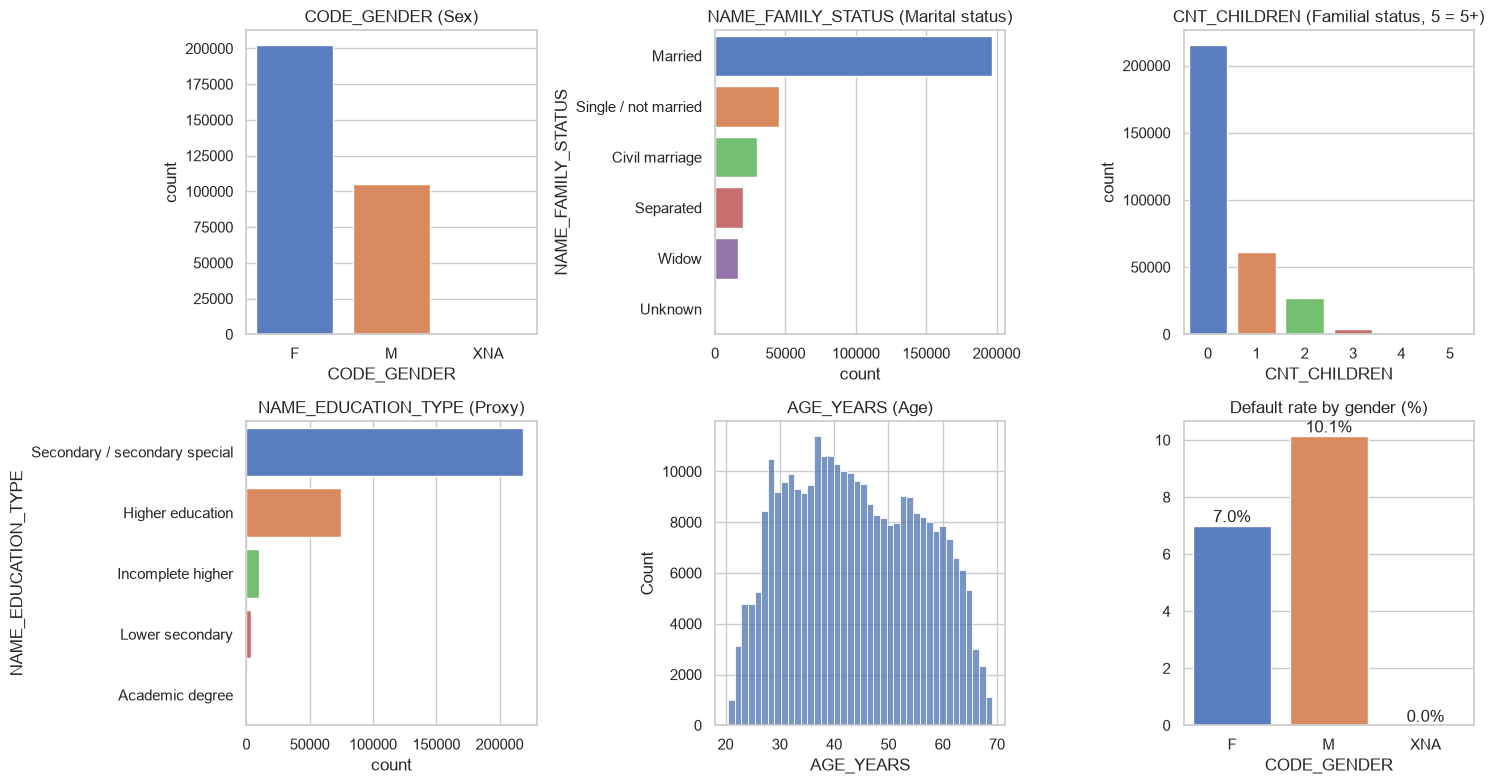

In [9]:
# Visualize the four discrete protected attributes + the age distribution.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# CODE_GENDER
sns.countplot(data=app, x="CODE_GENDER", ax=axes[0, 0],
              order=app["CODE_GENDER"].value_counts().index, palette="muted")
axes[0, 0].set_title("CODE_GENDER (Sex)")

# NAME_FAMILY_STATUS
sns.countplot(data=app, y="NAME_FAMILY_STATUS", ax=axes[0, 1],
              order=app["NAME_FAMILY_STATUS"].value_counts().index, palette="muted")
axes[0, 1].set_title("NAME_FAMILY_STATUS (Marital status)")

# CNT_CHILDREN (cap display at 5+ so rare large values don't stretch the axis)
children = app["CNT_CHILDREN"].clip(upper=5)
sns.countplot(x=children, ax=axes[0, 2], palette="muted")
axes[0, 2].set_title("CNT_CHILDREN (Familial status, 5 = 5+)")

# NAME_EDUCATION_TYPE
sns.countplot(data=app, y="NAME_EDUCATION_TYPE", ax=axes[1, 0],
              order=app["NAME_EDUCATION_TYPE"].value_counts().index, palette="muted")
axes[1, 0].set_title("NAME_EDUCATION_TYPE (Proxy)")

# AGE distribution
sns.histplot(app["AGE_YEARS"], bins=40, ax=axes[1, 1], color="#4C72B0")
axes[1, 1].set_title("AGE_YEARS (Age)")

# Default rate BY gender — a first glance at potential disparity
gender_rate = app.groupby("CODE_GENDER")["TARGET"].mean() * 100
sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[1, 2], palette="muted")
axes[1, 2].set_title("Default rate by gender (%)")
for i, v in enumerate(gender_rate.values):
    axes[1, 2].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "01_protected_attributes.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation & governance flags.**
- **Gender:** ~66% of applicants are female; male applicants default at a **noticeably
  higher rate** (~10% vs ~7%). A model can learn this — the audit must check it is not
  using sex as a shortcut. There are also **4 `XNA` (unknown) gender** rows — a small but
  real data-quality issue to resolve before fairness slicing.
- **Marital status:** dominated by *Married*; **2 `Unknown`** rows flagged.
- **Children / family:** highly skewed (most have 0); rare large counts are capped for display.
- **Education:** ~71% *Secondary*; **Academic degree** has only 164 rows → small subgroups
  will have **unstable metrics**, itself a fairness reporting risk.
- **Age:** ranges ~21–69 years. Age is a prohibited basis under ECOA, so age-correlated
  features (and `DAYS_BIRTH`) need explicit treatment in the audit.

These five attributes are now the **registered audit cohort** carried into `04_evaluation`.


## 6 · Missing values — a major data-quality issue

Missingness drives imputation strategy and is itself a **governance concern**: if data is
**missing not at random** across subgroups, naive imputation can *inject* bias. We quantify
it on the main table.


In [10]:
# Work on the ORIGINAL 122 columns (exclude the AGE_YEARS helper we derived in §5).
app_orig = app.drop(columns=["AGE_YEARS"])

# Percentage of missing values per column, highest first.
missing_pct = (app_orig.isna().mean() * 100).sort_values(ascending=False)

# Headline numbers.
n_with_missing = int((missing_pct > 0).sum())
print(f"Columns with at least one missing value: {n_with_missing} / {app_orig.shape[1]}")
print(f"Columns missing > 50%: {(missing_pct > 50).sum()}")
print(f"Columns missing > 60%: {(missing_pct > 60).sum()}\n")
print("Top 15 most-missing columns:")
print(missing_pct.head(15).round(1).to_string())

Columns with at least one missing value: 67 / 122
Columns missing > 50%: 41
Columns missing > 60%: 17

Top 15 most-missing columns:
COMMONAREA_MEDI             69.9
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
NONLIVINGAPARTMENTS_MEDI    69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_MODE       68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
FLOORSMIN_AVG               67.8
FLOORSMIN_MODE              67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_MEDI            66.5
YEARS_BUILD_MODE            66.5


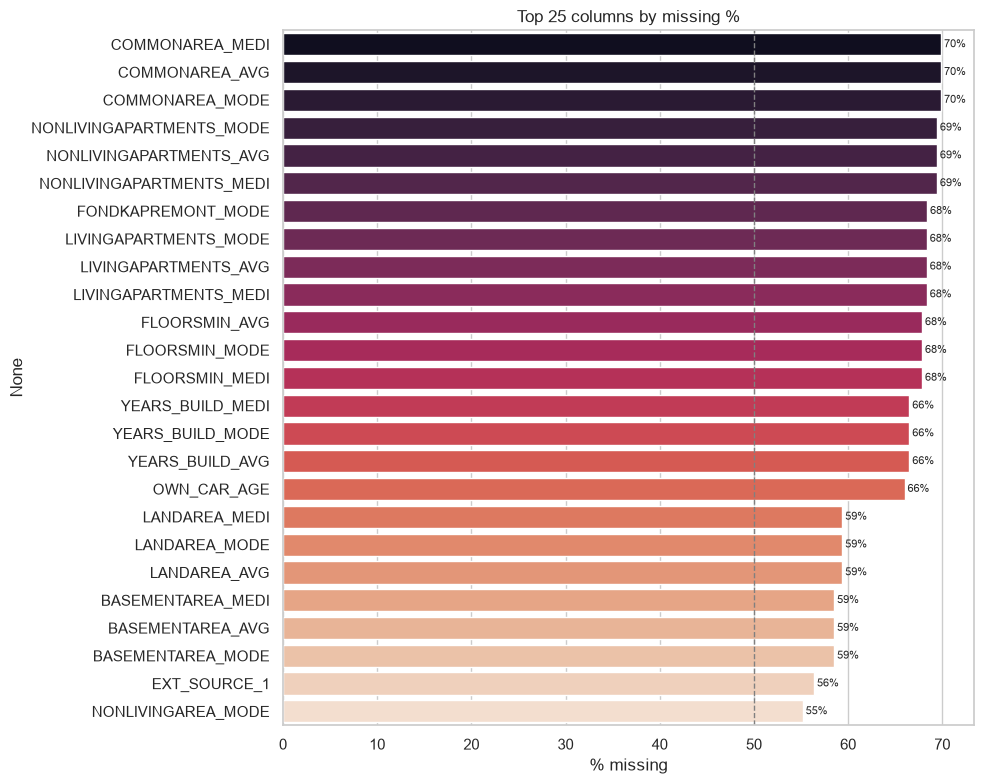

In [11]:
# Plot the 25 most-missing columns so the pattern is visible at a glance.
top_missing = missing_pct.head(25)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top_missing.values, y=top_missing.index, ax=ax, palette="rocket")
ax.set_title("Top 25 columns by missing %")
ax.set_xlabel("% missing")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)   # reference line at 50%
for i, v in enumerate(top_missing.values):                  # annotate each bar
    ax.text(v, i, f" {v:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "01_missing_values.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.**
- **67 of 122** columns have missing values; the worst (~**70%**) are all in the
  **Housing / building stats** block (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, …) — most
  are candidates to **drop**.
- Predictive fields are also affected: **`EXT_SOURCE_1`** is heavily missing and
  **`EXT_SOURCE_3`** partially missing — these are too valuable to drop, so they need
  **careful imputation** (and a flag indicating "was missing").
- **Action for `02`:** drop the high-missing housing block, impute `EXT_SOURCE_*` and other
  predictors, and **test whether missingness differs across the protected groups** from §5.


## 7 · Key takeaways & next step

**Data understanding — summary**
1. **10 tables (~2.5 GB)**; one hub (`application_train`, 307,511 × 122) + 9 auxiliary tables
   joined via `SK_ID_CURR` / `SK_ID_PREV` / `SK_ID_BUREAU`.
2. **TARGET is ~8.07% positive** (≈11.4 : 1 imbalance) → PR-AUC / recall / cost-sensitive
   threshold, not accuracy.
3. The **122 columns** fall into 13 business categories; the predictive core is small
   (external scores, amounts, demographics).
4. **Protected attributes registered:** `CODE_GENDER`, `NAME_FAMILY_STATUS`, `DAYS_BIRTH`(age),
   `CNT_CHILDREN`, `NAME_EDUCATION_TYPE` → carried into the Fair Lending audit.
5. **Heavy missingness** (67/122 cols; ~70% in the housing block) needs a documented,
   bias-aware imputation plan.

**Governance artifacts produced:** `results/01_target_distribution.png`,
`01_schema_diagram.png`, `01_protected_attributes.png`, `01_missing_values.png`.

---
### ➡️ Next: `02_eda_main_table`
Deep-dive EDA on `application_train`: feature-vs-TARGET relationships, the `EXT_SOURCE`
predictors, outliers (e.g. the `DAYS_EMPLOYED` 365243 sentinel), and **subgroup default
rates** that set up the fairness audit.
